In [68]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import importlib
sns.set_theme(style="whitegrid", context="talk")
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

sys.path.append(os.path.abspath(".."))
%load_ext autoreload
%autoreload 2
    
from data_features.data_features import load_coupled_panel
from data_features.data_features import build_features
from data_features.data_features import make_t_plus_1_targets_winsorized

from models.models import add_har_rv_parallel
from models.models import feature_selection
from models.models import detect_markov_regime
from models.models import add_regime_probs_to_panel
from models.models import optimise_xgb_params_optuna
from models.models import two_regime_rolling_cv_per_country
from models.models import compute_vol_regime_flag

from diagnostics.diagnostics import baseline_check
from diagnostics.diagnostics import plot_cv_diagnostics
from diagnostics.diagnostics import plot_ic_stability

from trading.trading import compute_market_neutral_pnl_adaptive
from trading.trading import evaluate_trading_performance
from trading.trading import build_price_panel
from trading.trading import merge_rolling_scale_into_bt

from dask.distributed import Client
#client = Client("tcp://... scheduler ip") # part of a set up of dask scheduler and workers for parallel execution
#client

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Example of price/volatility data

/home/tatiana/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


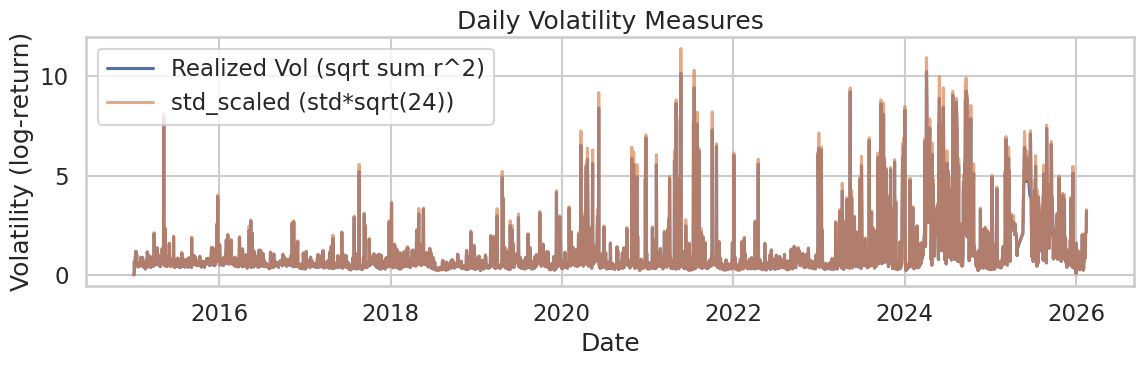

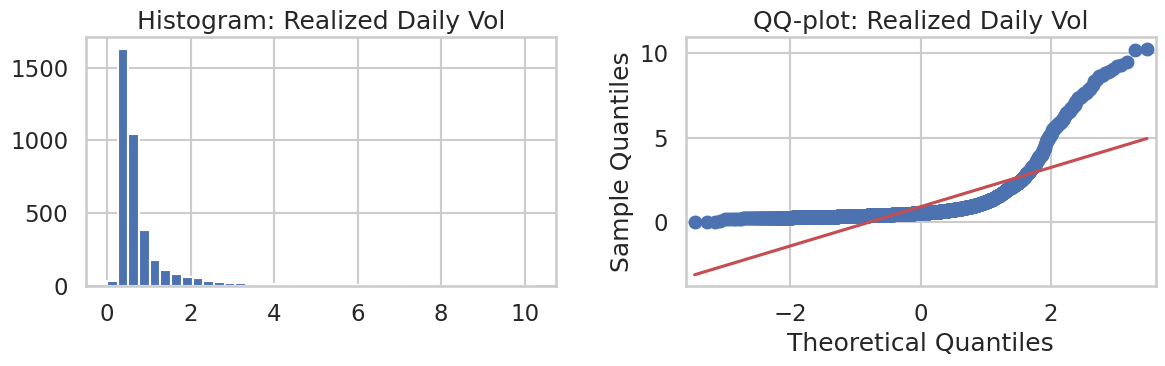

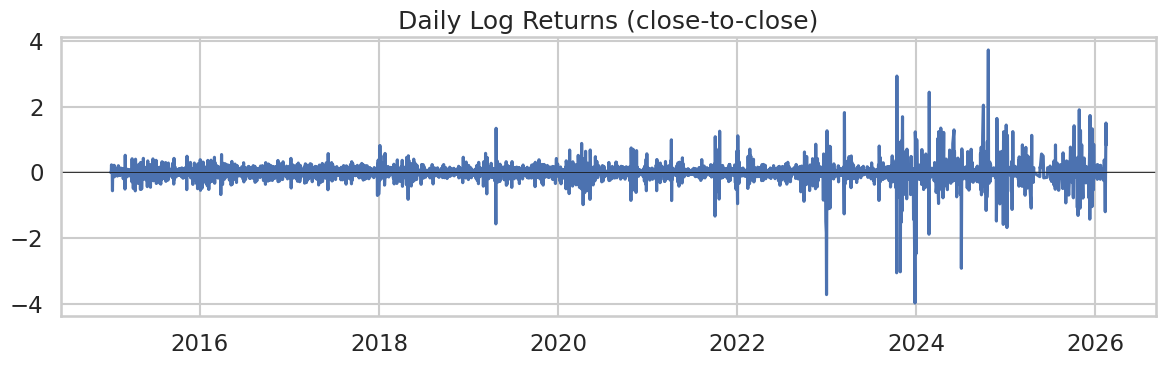

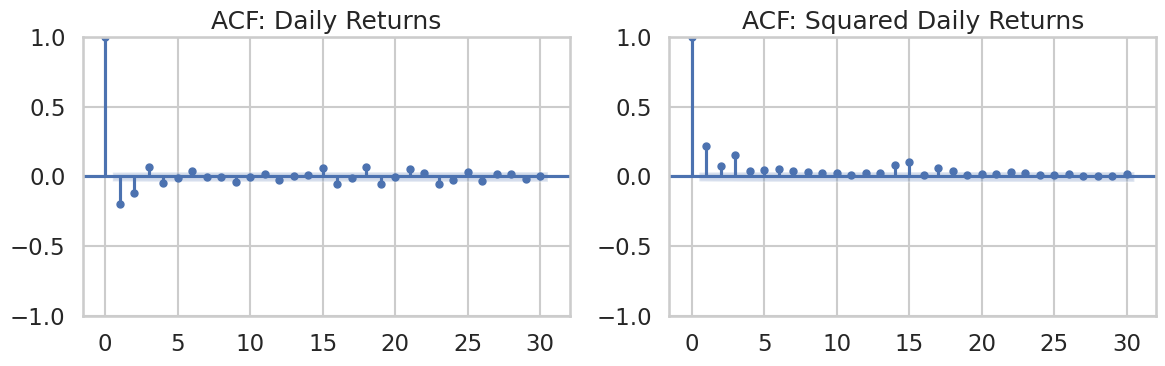

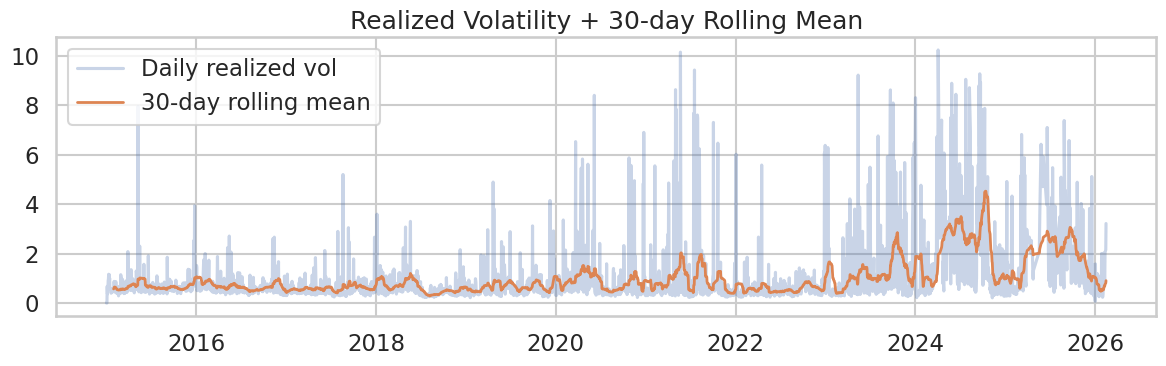

In [4]:
fn = "european_wholesale_electricity_price_data_hourly/France.csv"

# parse dates, prefer local datetime column for daily aggregation
df = pd.read_csv(fn, parse_dates=['Datetime (Local)'])

# columns: Country, ISO3 Code, Datetime (UTC), Datetime (Local), Price (EUR/MWhe)
# keep only the local datetime and price
df = df[['Datetime (Local)', 'Price (EUR/MWhe)']].copy()
df = df.rename(columns={'Datetime (Local)': 'datetime', 'Price (EUR/MWhe)': 'price'})
df = df.sort_values('datetime').set_index('datetime')
df.index = pd.to_datetime(df.index)  # ensure datetime index

# ---------------------------
# Hourly returns
# ---------------------------
# compute log returns (natural log)
df['log_price'] = np.log(df['price'].replace(0, np.nan))
df['hourly_ret'] = df['log_price'].diff()
df = df.dropna(subset=['hourly_ret'])  # drop first NA

# ---------------------------
# Daily volatility measures
# ---------------------------
# Option A: Realized volatility (square-root of sum of squared intraday returns)
# Option B: Daily std of hourly returns scaled by sqrt(24) (if hours per day ~24)
# Guard against days with missing hours (e.g., DST or missing data)
min_hours_required = 20  # drop days with fewer than this many hourly observations

# attach a date column for grouping (local date)
df['date'] = df.index.normalize()  # midnight-normalized date

group = df.groupby('date')

# count hours per day
counts = group['hourly_ret'].count().rename('n_hours')

daily = pd.DataFrame({
    'n_hours': counts,
})

# realized volatility: sqrt(sum(r_i^2))
daily['realized_vol'] = group['hourly_ret'].apply(lambda x: np.sqrt(np.sum(x.values**2)))

# scaled std: std(hourly returns) * sqrt(24)  (common approximation)
daily['std_scaled'] = group['hourly_ret'].std() * np.sqrt(24)

# daily log return using last observation each day (close-to-close)
daily_close = df['log_price'].resample('D').last()
daily['daily_log_return'] = daily_close.diff().reindex(daily.index)

# filter days with too few hours (optional, recommended)
daily = daily[daily['n_hours'] >= min_hours_required]

# drop any rows with NaNs where it matters
daily = daily.dropna(subset=['realized_vol', 'std_scaled', 'daily_log_return'])

# ---------------------------
# Plotting
# ---------------------------
plt.rcParams['figure.figsize'] = (12, 4)

# Time series of realized volatility
plt.figure()
plt.plot(daily.index, daily['realized_vol'], label='Realized Vol (sqrt sum r^2)')
plt.plot(daily.index, daily['std_scaled'], label='std_scaled (std*sqrt(24))', alpha=0.7)
plt.legend()
plt.title('Daily Volatility Measures')
plt.xlabel('Date')
plt.ylabel('Volatility (log-return)')
plt.tight_layout()
plt.show()

# Histogram + QQplot of daily volatility
plt.figure()
plt.subplot(1,2,1)
plt.hist(daily['realized_vol'].dropna(), bins=40)
plt.title('Realized Daily Vol')
plt.subplot(1,2,2)
qqplot(daily['realized_vol'].dropna(), line='s', ax=plt.gca())
plt.title('QQ-plot: Realized Daily Vol')
plt.tight_layout()
plt.show()

# Time series of daily returns 
plt.figure()
plt.plot(daily.index, daily['daily_log_return'])
plt.title('Daily Log Returns (close-to-close)')
plt.axhline(0, color='k', linewidth=0.6)
plt.tight_layout()
plt.show()

# ACF of returns and squared returns
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plot_acf(daily['daily_log_return'].dropna(), lags=30, ax=plt.gca(), title='ACF: Daily Returns')
plt.subplot(1,2,2)
plot_acf(daily['daily_log_return'].dropna()**2, lags=30, ax=plt.gca(), title='ACF: Squared Daily Returns')
plt.tight_layout()
plt.show()

# Rolling volatility plot 
plt.figure()
rolling = daily['realized_vol'].rolling(window=30).mean()
plt.plot(daily.index, daily['realized_vol'], alpha=0.3, label='Daily realized vol')
plt.plot(daily.index, rolling, label='30-day rolling mean', linewidth=2)
plt.legend()
plt.title('Realized Volatility + 30-day Rolling Mean')
plt.tight_layout()
plt.show()

# Demo / current results

### Loading data, printing contents

In [9]:
panel = load_coupled_panel("daily_merged_full_germany.csv", 
                           "daily_merged_full_france.csv")

print(panel.columns.tolist())
panel.head()

['DATE', 'DE_realized_vol', 'DE_daily_log_return', 'DE_temp_C', 'DE_wind_speed', 'DE_precip', 'DE_Biomass_Actual_Aggregated', 'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'DE_Fossil_Coal_derived_gas_Actual_Aggregated', 'DE_Fossil_Gas_Actual_Aggregated', 'DE_Fossil_Hard_coal_Actual_Aggregated', 'DE_Fossil_Oil_Actual_Aggregated', 'DE_Geothermal_Actual_Aggregated', 'DE_Hydro_Pumped_Storage_Actual_Aggregated', 'DE_Hydro_Pumped_Storage_Actual_Consumption', 'DE_Hydro_Run_of_river_and_poundage_Actual_Aggregated', 'DE_Hydro_Water_Reservoir_Actual_Aggregated', 'DE_Other_Actual_Aggregated', 'DE_Other_renewable_Actual_Aggregated', 'DE_Solar_Actual_Aggregated', 'DE_Solar_Actual_Consumption', 'DE_Waste_Actual_Aggregated', 'DE_Wind_Offshore_Actual_Aggregated', 'DE_Wind_Onshore_Actual_Aggregated', 'DE_Wind_Onshore_Actual_Consumption', 'DE_Fossil_Brown_coal_Lignite_Actual_Consumption', 'DE_Fossil_Coal_derived_gas_Actual_Consumption', 'DE_Fossil_Gas_Actual_Consumption', 'DE_Fossil_Hard_coal_Actual

,DATE,DE_realized_vol,DE_daily_log_return,DE_temp_C,DE_wind_speed,DE_precip,DE_Biomass_Actual_Aggregated,DE_Fossil_Brown_coal_Lignite_Actual_Aggregated,DE_Fossil_Coal_derived_gas_Actual_Aggregated,DE_Fossil_Gas_Actual_Aggregated,...,FR_Wind_Onshore_Actual_Consumption,FR_Energy_storage_Actual_Aggregated,FR_Energy_storage_Actual_Consumption,FR_Fossil_Oil_Actual_Consumption,FR_total_generation,FR_wind_total,FR_wind_share,FR_solar_total,FR_solar_share,FR_load_MW
0,2015-01-30,0.581994,0.061458,0.171051,3.714694,0.000136,4702.510000,17854.666250,0.0,1492.348750,...,NaN,NaN,NaN,NaN,74468.000000,NaN,NaN,0.000000,0.000000,68927.000000
1,2015-01-31,0.460251,-0.055179,-0.200287,3.407336,0.000074,4749.933125,17275.562604,0.0,1760.052604,...,NaN,NaN,NaN,NaN,76474.666667,NaN,NaN,393.000000,0.005139,68780.250000
2,2015-02-01,0.445206,0.051841,-0.188416,3.670489,0.000098,4738.595313,17634.286458,0.0,1650.192917,...,NaN,NaN,NaN,NaN,76911.458333,NaN,NaN,408.583333,0.005312,67595.166667
3,2015-02-02,0.588018,0.253294,-0.011078,4.111092,0.000097,4689.908958,18220.183854,0.0,2545.774271,...,NaN,NaN,NaN,NaN,80408.208333,NaN,NaN,459.250000,0.005711,76580.708333
4,2015-02-03,0.732238,-0.116378,-1.376923,3.025634,0.000026,4682.821042,17978.253125,0.0,3772.018021,...,NaN,NaN,NaN,NaN,81256.541667,NaN,NaN,309.583333,0.003810,79182.291667


### Building a few lagged/cross-country features out of raw data

In [10]:
panel_feat = build_features(panel)

## HAR-RV modeling and diagnostics block
- Longer observation window for Germany and shorter for France yields better results, due to difference in their regime/s structure
- This method is definitely superior to GARCH(1,1) (used previously) for this data and is used for further steps.
- It cannot efficiently account for certain data features, such as weekly patterns

In [11]:
panel_harrv, metrics_harrv = add_har_rv_parallel(
    panel_feat,
    min_obs = 150,
    window={"DE": 500, "FR": 200}
)
metrics_harrv

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    0.7s finished


{'DE': {'spearman_ic': np.float64(0.6685400292043947),
  'rmse': 0.9368304461497873,
  'mae': 0.4746361429154902},
 'FR': {'spearman_ic': np.float64(0.6630367015385233),
  'rmse': 1.2339308195208576,
  'mae': 0.5630951480479406}}


--- DE Baseline diagnostics ---
rows: 4034
nan sigma: 150 (3.7%)
nan realized: 0 (0.0%)
valid pairs: 3884
spearman(log real, log sigma): 0.6685


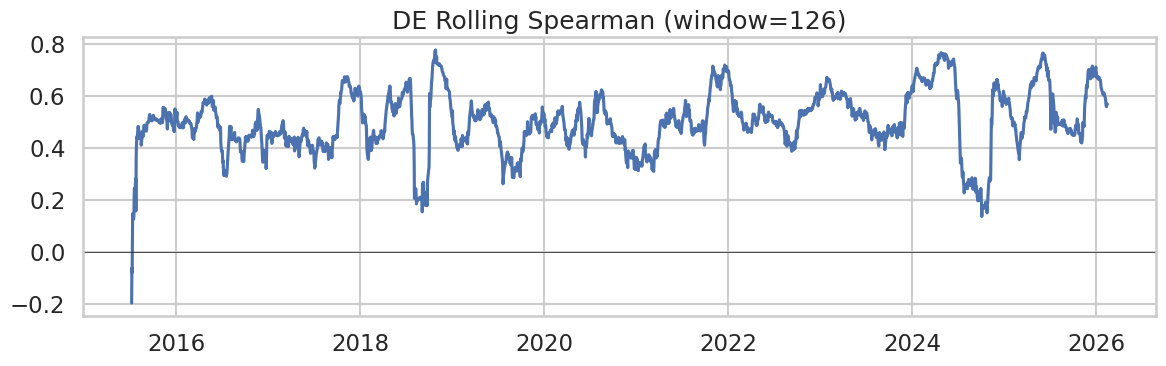

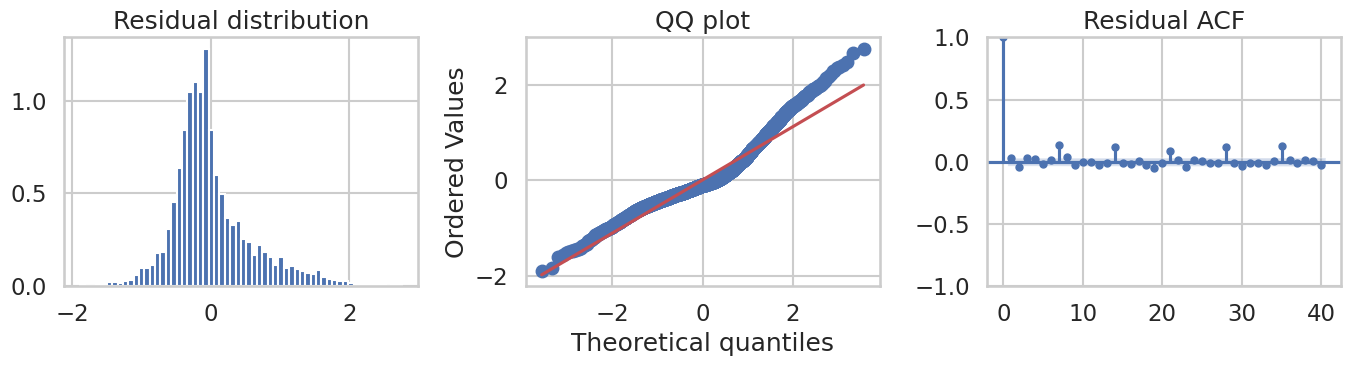

residual mean=0.0109  std=0.5772  skew=1.0421

--- FR Baseline diagnostics ---
rows: 4034
nan sigma: 150 (3.7%)
nan realized: 0 (0.0%)
valid pairs: 3884
spearman(log real, log sigma): 0.6630


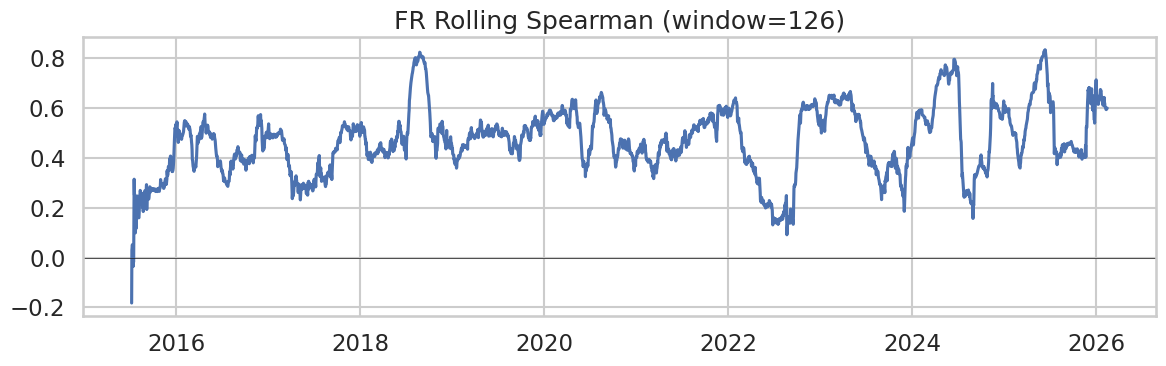

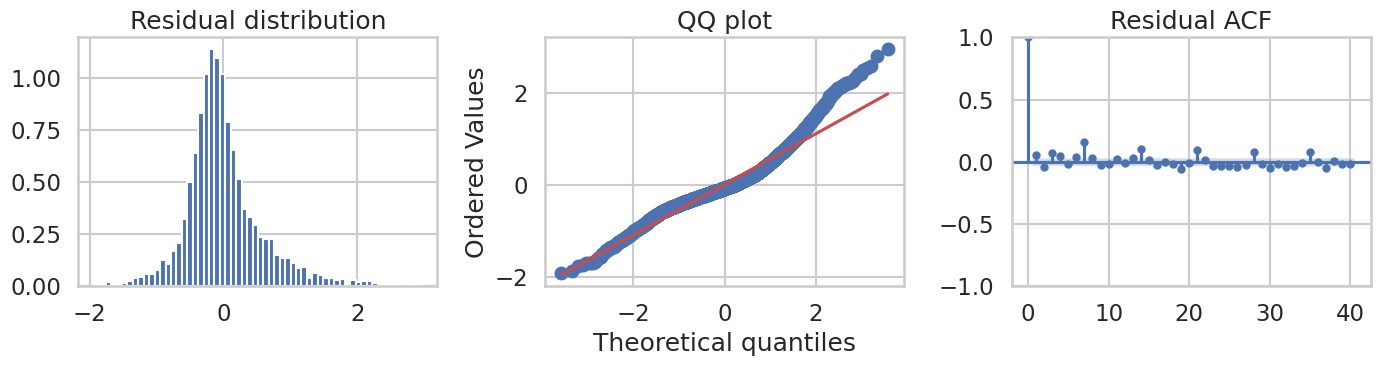

residual mean=0.0062  std=0.5687  skew=0.9583


In [12]:
roll_de = baseline_check(panel_harrv, "DE")

roll_fr = baseline_check(panel_harrv, "FR")

### Creating prediction target: computing vol residuals (realized vol - baseline), shifting to t+1

In [13]:
panel_harrv_res = make_t_plus_1_targets_winsorized(panel_harrv, winsor_pct=0)

[target stats] DE_residual_target: n=3884  mean=0.011  std=0.577  skew=1.042  [-1.12, 1.79]
[target stats] FR_residual_target: n=3884  mean=0.006  std=0.569  skew=0.958  [-1.25, 1.93]
[target stats] DE_log_rv_target: n=4033  mean=-0.374  std=0.753  skew=0.970  [-1.69, 1.68]
[target stats] FR_log_rv_target: n=4033  mean=-0.306  std=0.792  skew=1.324  [-1.34, 2.04]


### Selecting most important features for further ML training
- Runs pre-filter on full set first, then rolling windows, like in CV.
- Hard limits on pre-filtered and final selection can be set.
- Regime-aware (uses vol z-score as detector), feature importance can be adjusted based on regime; **but it is probably better to do feature selection in the main CV**.

In [23]:
selected_features, diagnostics = feature_selection(panel_harrv_res, 
                                                    train_window = 1200,
                                                    prefilter_top_k = 20,
                                                    max_features = 10,
                                                    freq_threshold = 0.70,
                                                    freq_threshold_regime = 0.45)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:   11.1s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:   20.8s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed:   30.5s
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:   36.3s
[Parallel(n_jobs=-1)]: Done 173 out of 178 | elapsed:   48.6s remaining:    1.4s



=== FEATURE SELECTION DIAGNOSTICS ===
Folds: 178  (pre-2022: 107, post-2022: 71)
Train window: 1200 days (rolling)
Freq threshold: global=0.7, per-regime=0.45
Vol zscore regime split: True
Avg prefilter kept: DE=20.0, FR=20.0
Avg selected per fold: DE=9.8, FR=9.7
Stable DE: 10  Stable FR: 9
Calendar features forced (prefixed only): 0
Union total: 18

--- Fold-averaged metrics ---
DE: train IC=0.4945  test IC=0.3541  gap=0.1404
FR: train IC=0.4170  test IC=0.2366  gap=0.1803

Stable DE features: ['DE_daily_log_return', 'DE_res_load', 'DE_Fossil_Hard_coal_Actual_Aggregated', 'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'DE_Fossil_Gas_Actual_Aggregated', 'DE_load_MW_lag7', 'DE_wind_speed', 'DE_Hydro_Pumped_Storage_Actual_Aggregated', 'VOL_SPREAD', 'DE_Hydro_Water_Reservoir_Actual_Aggregated']
Stable FR features: ['FR_daily_log_return', 'FR_Fossil_Gas_Actual_Aggregated', 'FR_load_MW_lag7', 'FR_wind_speed', 'FR_Hydro_Water_Reservoir_Actual_Aggregated', 'FR_Fossil_Hard_coal_Actual_Aggr

[Parallel(n_jobs=-1)]: Done 178 out of 178 | elapsed:   49.2s finished


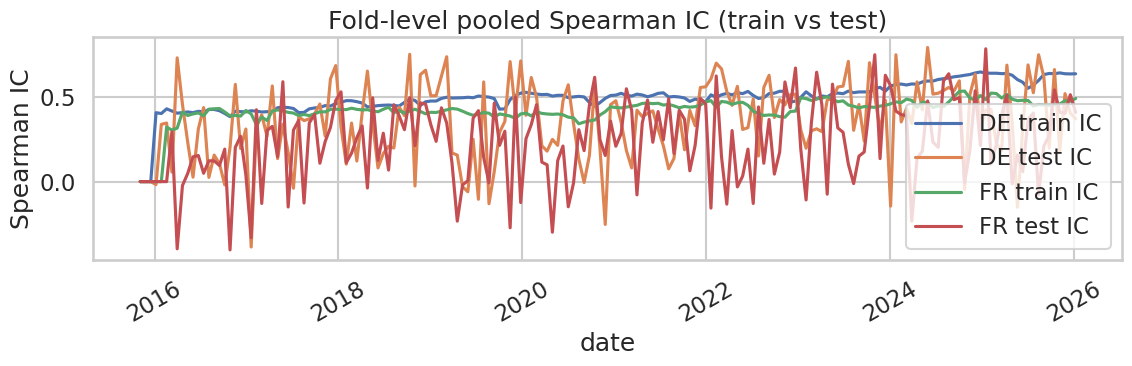

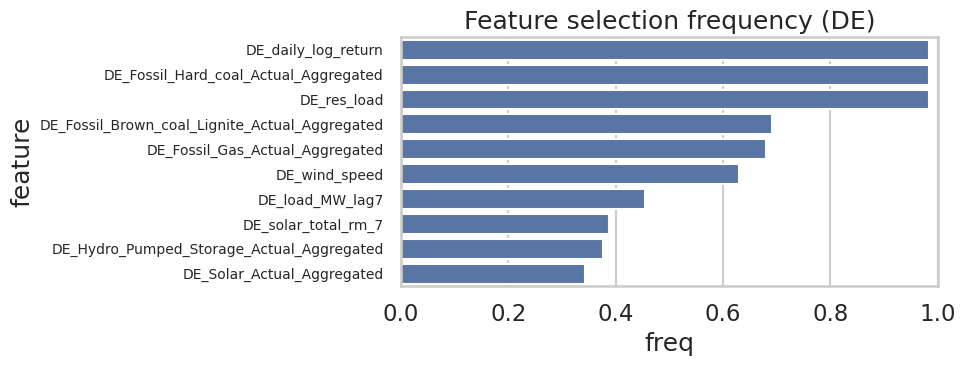

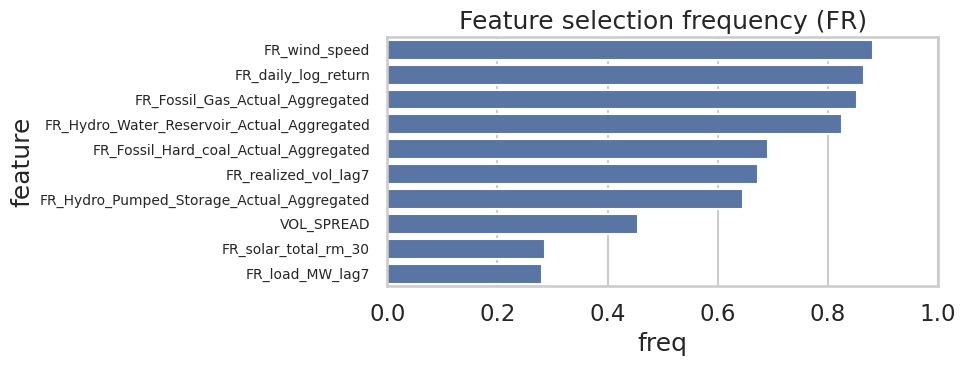

In [24]:
# assume `diagnostics` exists from function call
folds = diagnostics["folds"].copy()
folds["train_until"] = pd.to_datetime(folds["train_until"])

# 1) Train / Test IC over folds
plt.figure(figsize=(12,4))
if "DE_train_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_train_ic", label="DE train IC")
if "DE_test_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_test_ic", label="DE test IC")
if "FR_train_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_train_ic", label="FR train IC")
if "FR_test_ic" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_test_ic", label="FR test IC")
plt.title("Fold-level pooled Spearman IC (train vs test)")
plt.ylabel('Spearman IC')
plt.xlabel('date')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()

"""
# 2) Train / Test RMSE over folds
plt.figure(figsize=(12,4))
if "DE_train_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_train_rmse", label="DE train RMSE")
if "DE_test_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="DE_test_rmse", label="DE test RMSE")
if "FR_train_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_train_rmse", label="FR train RMSE")
if "FR_test_rmse" in folds:
    sns.lineplot(data=folds, x="train_until", y="FR_test_rmse", label="FR test RMSE")
plt.title("Fold-level RMSE (train vs test)")
plt.ylabel('RMSE')
plt.xlabel('date')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()
"""
# 3) Feature selection frequency (top 15) per country
freq_de = diagnostics.get("freq_de", {})
freq_fr = diagnostics.get("freq_fr", {})
def plot_top_freq(freq_map, title, top_n=10):
    if not freq_map:
        print("No freq data for", title)
        return
    df_freq = pd.DataFrame(list(freq_map.items()), columns=["feature","freq"])
    df_freq = df_freq.sort_values("freq", ascending=False).head(top_n)
    plt.figure(figsize=(10, max(4, 0.2*len(df_freq))))
    sns.barplot(x="freq", y="feature", data=df_freq)
    plt.yticks(fontsize=10) 
    plt.title(title)
    plt.xlim(0,1)
    plt.tight_layout()
    plt.show()

plot_top_freq(freq_de, "Feature selection frequency (DE)")
plot_top_freq(freq_fr, "Feature selection frequency (FR)")

In [16]:
## Selected feature override -- using hand-picked sensible variables, removing redundancy and trying to handle overfitting
selected_features = ['DE_daily_log_return','DE_res_load', 'DE_Fossil_Hard_coal_Actual_Aggregated',
                     'DE_Fossil_Brown_coal_Lignite_Actual_Aggregated', 'VOL_SPREAD',
                     
                     'FR_res_load','FR_daily_log_return', 
                      'FR_Fossil_Gas_Actual_Aggregated',
                     'FR_Hydro_Water_Reservoir_Actual_Aggregated','FR_realized_vol_lag7']

### An example of HMM regime detection for France and diagnostics
- Just a demo here, used on full data sample.
- This function is further used in the rolling window logic with XGBoost to avoid lookahead.
- Used on **log of realized volatility** in the main file, here just on raw values, again, just for demo.
- Clear regime separation can be seen from state counts and their means below (should be significantly different).
- Here corrected 2 **Gaussian-mix** version is used, which is somewhat more appropriate for the (tailed skewed) data and better separates the regimes than the 1-Gaussian.

In [17]:
fr_regimes, fr_diag = detect_markov_regime(
    panel_harrv_res,
    residual_col="FR_realized_vol"
)

print('transition matrix = \n', fr_diag["transition_matrix"])
print('state means = ', fr_diag["means"])
print('state counts = ', fr_diag["state_counts"])

transition matrix = 
 [[0.94001639 0.05998361]
 [0.17750694 0.82249306]]
state means =  [0.45380346 0.75889068 1.5866558  5.06521465]
state counts =  [3063  971]


Text(0.5, 0, 'time axis')

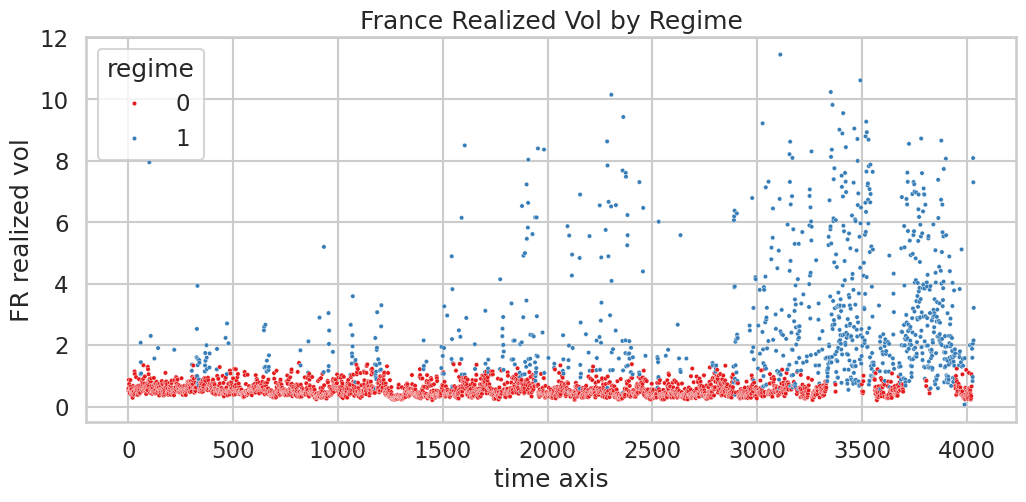

In [18]:
plt.figure(figsize=(12,5))
sns.scatterplot(x=fr_regimes.index,
    y=fr_regimes["FR_realized_vol"],
    hue=fr_regimes["regime"],
    palette="Set1",
    s=10
)
plt.title("France Realized Vol by Regime")
plt.ylabel('FR realized vol')
plt.xlabel('time axis')

## Main XGBoost forecasting block and diagnostics
- Forecasting **different targets depending on the regime**: calm regime -- log of RV directly (no HAR-RV baseline subtraction), high-vol regime -- residual of RV (after baseline subtraction)
- Running in **rolling windows**, to account for persistency in regime changes (thus older data being less useful to predict in current regime).
- Tried a range of windows, found optimum at 1200 days.
- Optuna -- **Bayesian-based hyperparameter optimization** runs in folds with inner train-val splits.
- **Overfitting (train/test) gap is ~0.10** for DE and FR, meaning some 25% of learned structure does not generalize. Can still attempt to improve, without losing too much signal, by e.g. selecting features in the main CV (potentially better corresponding to the regime) and optimizing hyperparameters for this specific set.
- **Vol z-score** is used for **regime detection**, somewhat simpler and seems to work better than HMM, even the 2-Gaussian one. Might try to tweak the HMM or try other regime detectors like statistical jump.

In [55]:
#panel_with_regimes, regime_diags = add_regime_probs_to_panel(
#    panel_harrv_res, countries=['DE', 'FR'])

all_preds, cv_metrics = two_regime_rolling_cv_per_country(
    panel_harrv_res, selected_features,
    use_regime_targets=True,
    vol_regime_window=252,
    vol_regime_threshold=0.5,
    train_window = 1200,
    use_markov={'DE': False, 'FR': False},       
    use_per_regime_models = False,
    use_vol_zscore={'DE': True, 'FR': True}
)

[CV] Shared features: ['VOL_SPREAD']
Regime-conditional targets: DE high-vol folds=30/178, FR high-vol folds=33/178
=== SUMMARY ===
Pooled IC: 0.6694
Per-country IC: {'DE': 0.645450914780067, 'FR': 0.6958901193001586}
Mean fold ICs — DE: 0.4483  FR: 0.3793


In [56]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

all_preds = all_preds.sort_values('DATE').reset_index(drop=True)

for c in ['DE', 'FR']:
    idx = all_preds[all_preds['COUNTRY'] == c].index  # integer positions in all_preds
    sub = all_preds.loc[idx].copy()

    err = (sub['pred'] - sub['true']).reset_index(drop=True)

    # Build AR(7) design matrix on the error series
    X_ar = pd.concat([err.shift(i) for i in range(1, 8)], axis=1)
    X_ar.columns = [f'lag_{i}' for i in range(1, 8)]

    valid = X_ar.dropna().index  # rows where all 7 lags are available
    X_fit = sm.add_constant(X_ar.loc[valid])
    y_fit = err.loc[valid]

    ar_model = OLS(y_fit, X_fit).fit()
    correction = ar_model.fittedvalues  # indexed by valid (0-based within sub)

    # Map back: valid is 0-based within sub, idx gives all_preds positions
    all_preds.loc[idx[valid], 'pred'] -= correction.values

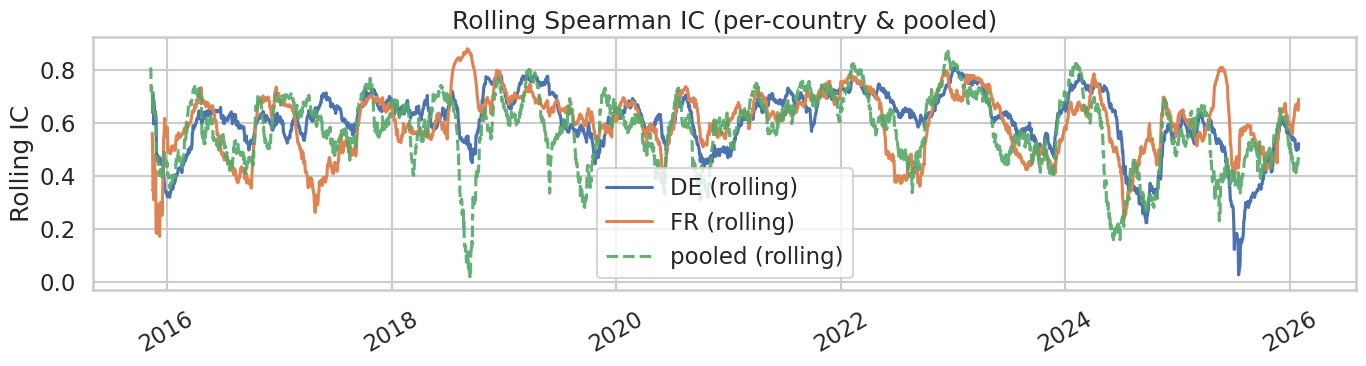

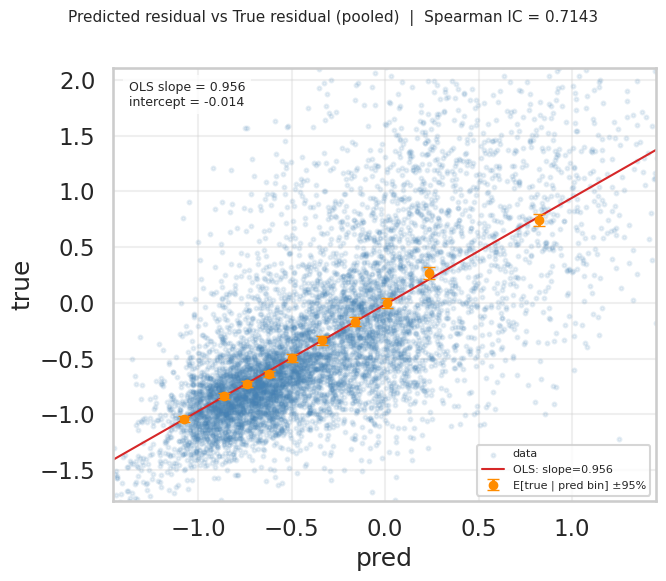

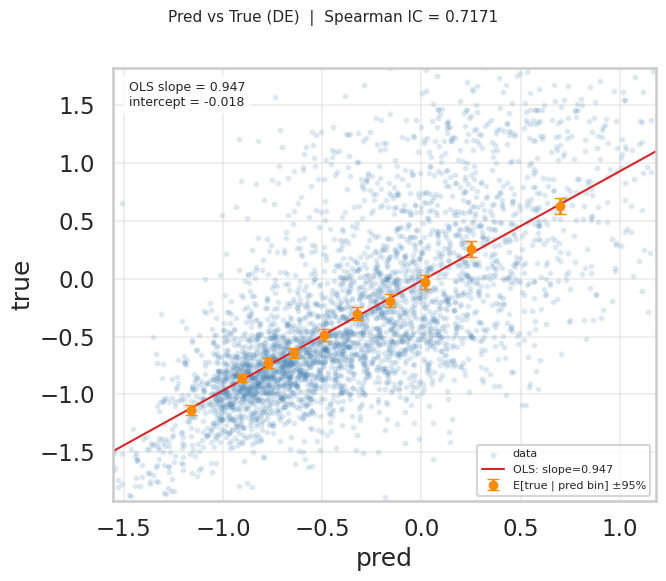

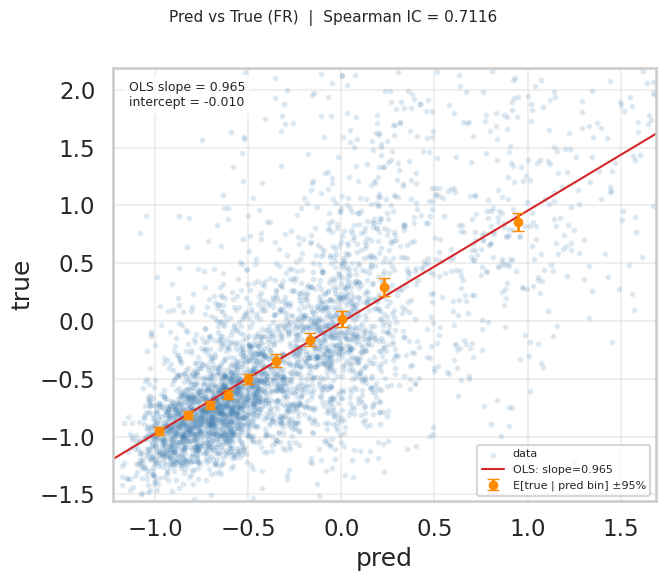

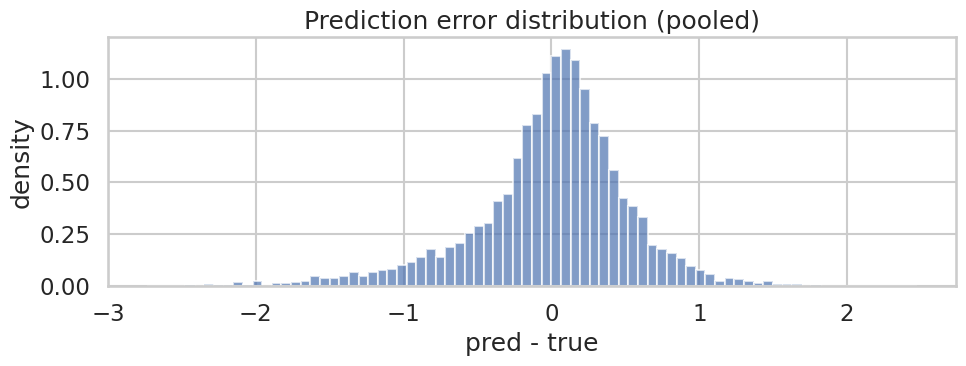

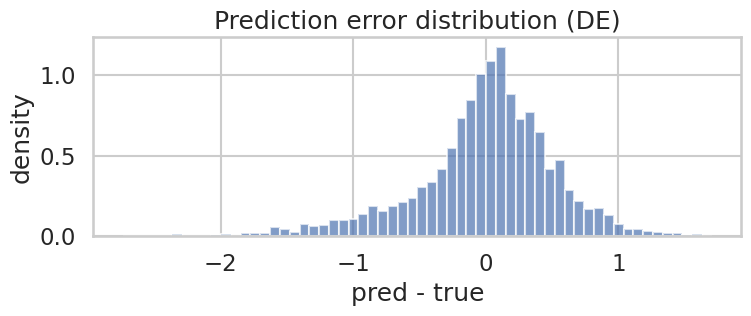

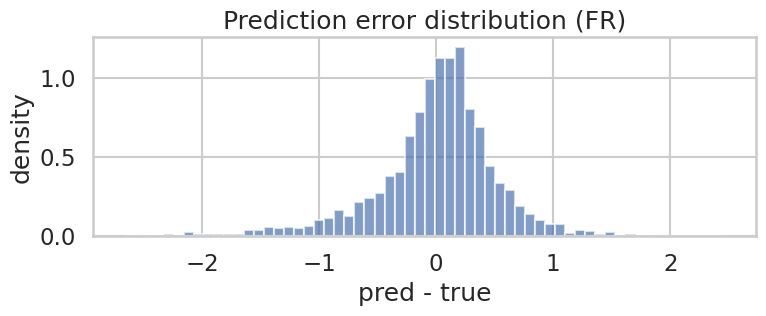

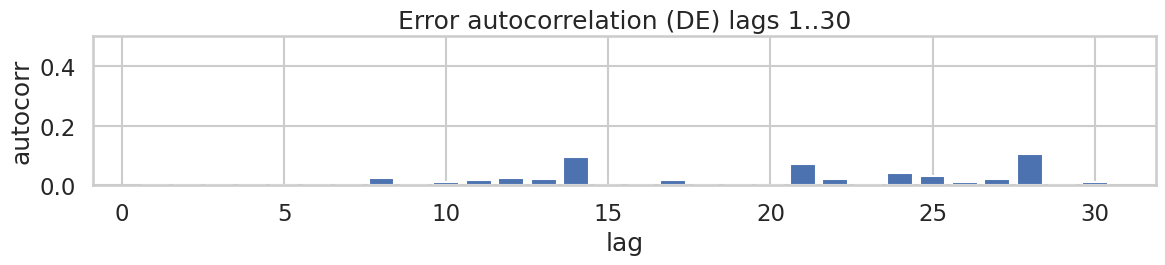

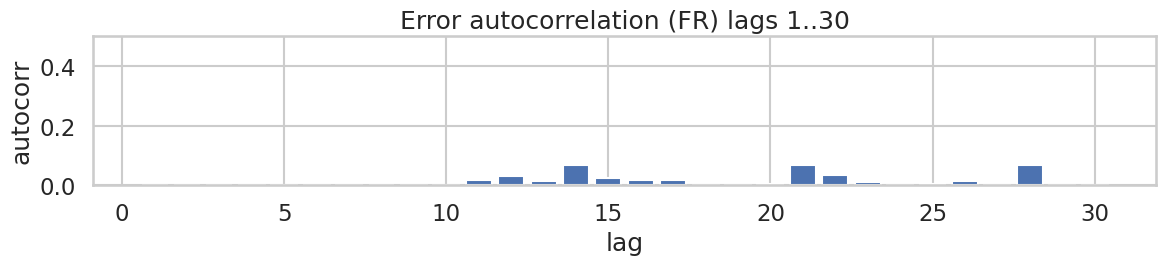

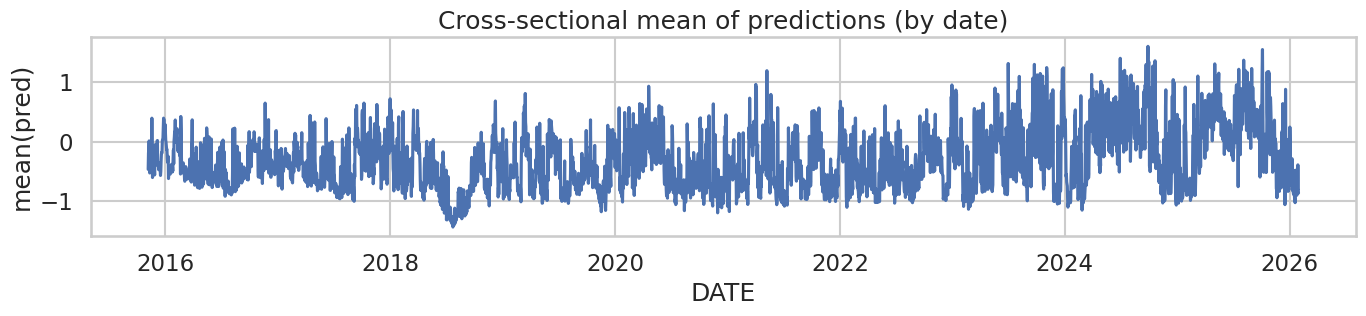

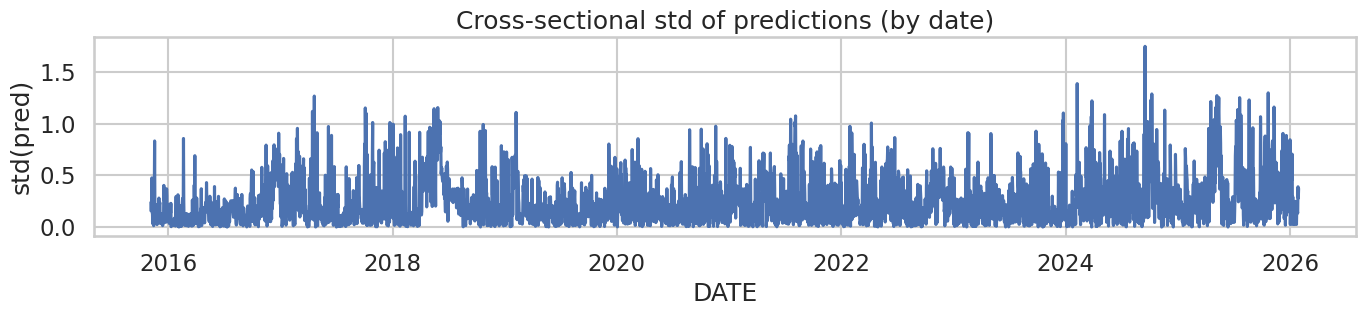

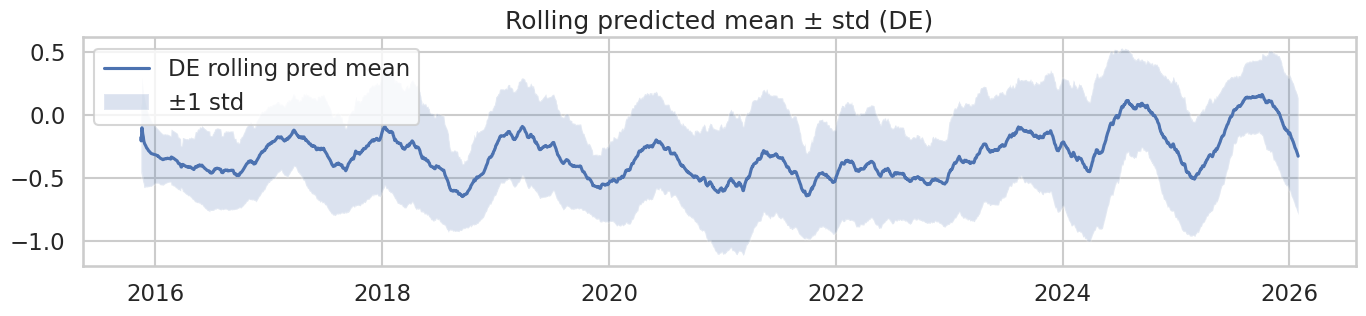

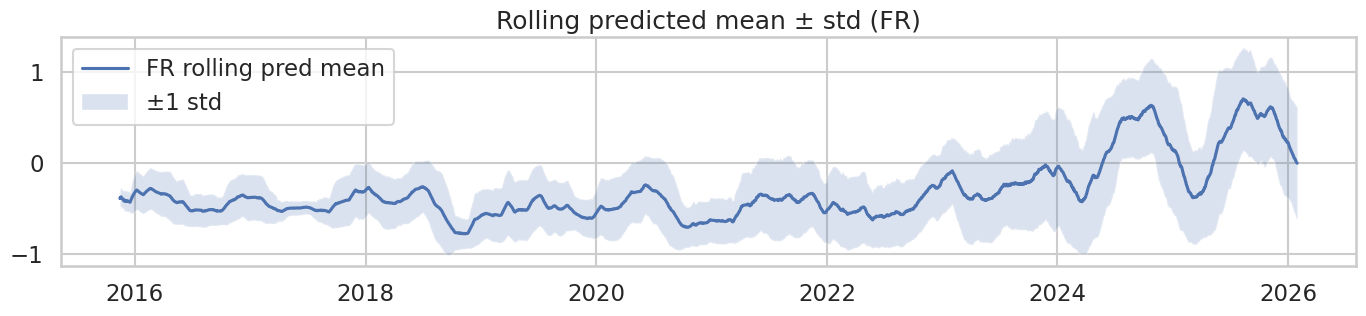

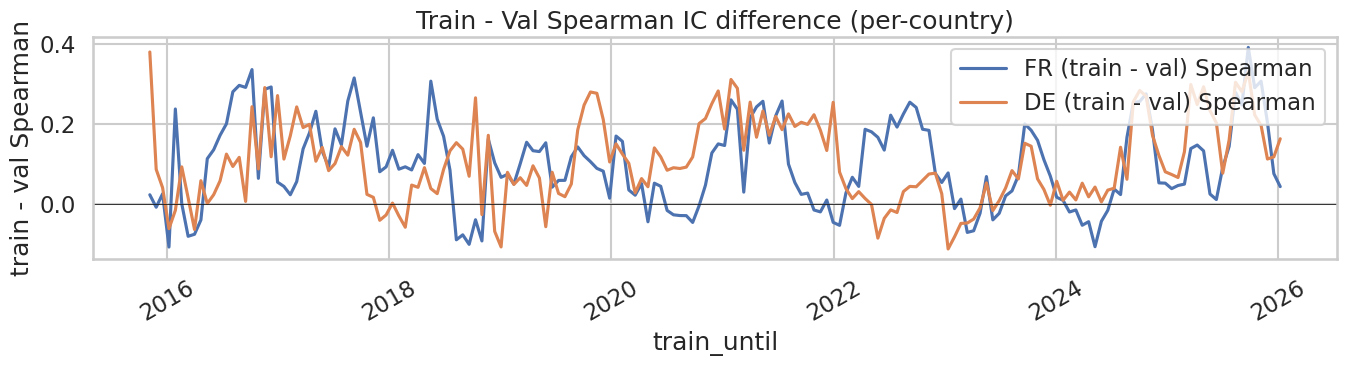

diff. IC train-val, FR: 0.099
diff. IC train-val, DE: 0.104
=== SUMMARY ===
Pooled IC: 0.6694401020191089
Per-country IC: {'DE': 0.645450914780067, 'FR': 0.6958901193001586}
Mean fold ICs (DE/FR): 0.4483073016058831 0.3792525309246557
Mean RMSE (fold mean): 0.5209023317406458
Pooled RMSE / MAE: 0.5562519746168904 0.40593647640682184


In [57]:
plot_cv_diagnostics(all_preds, cv_metrics)

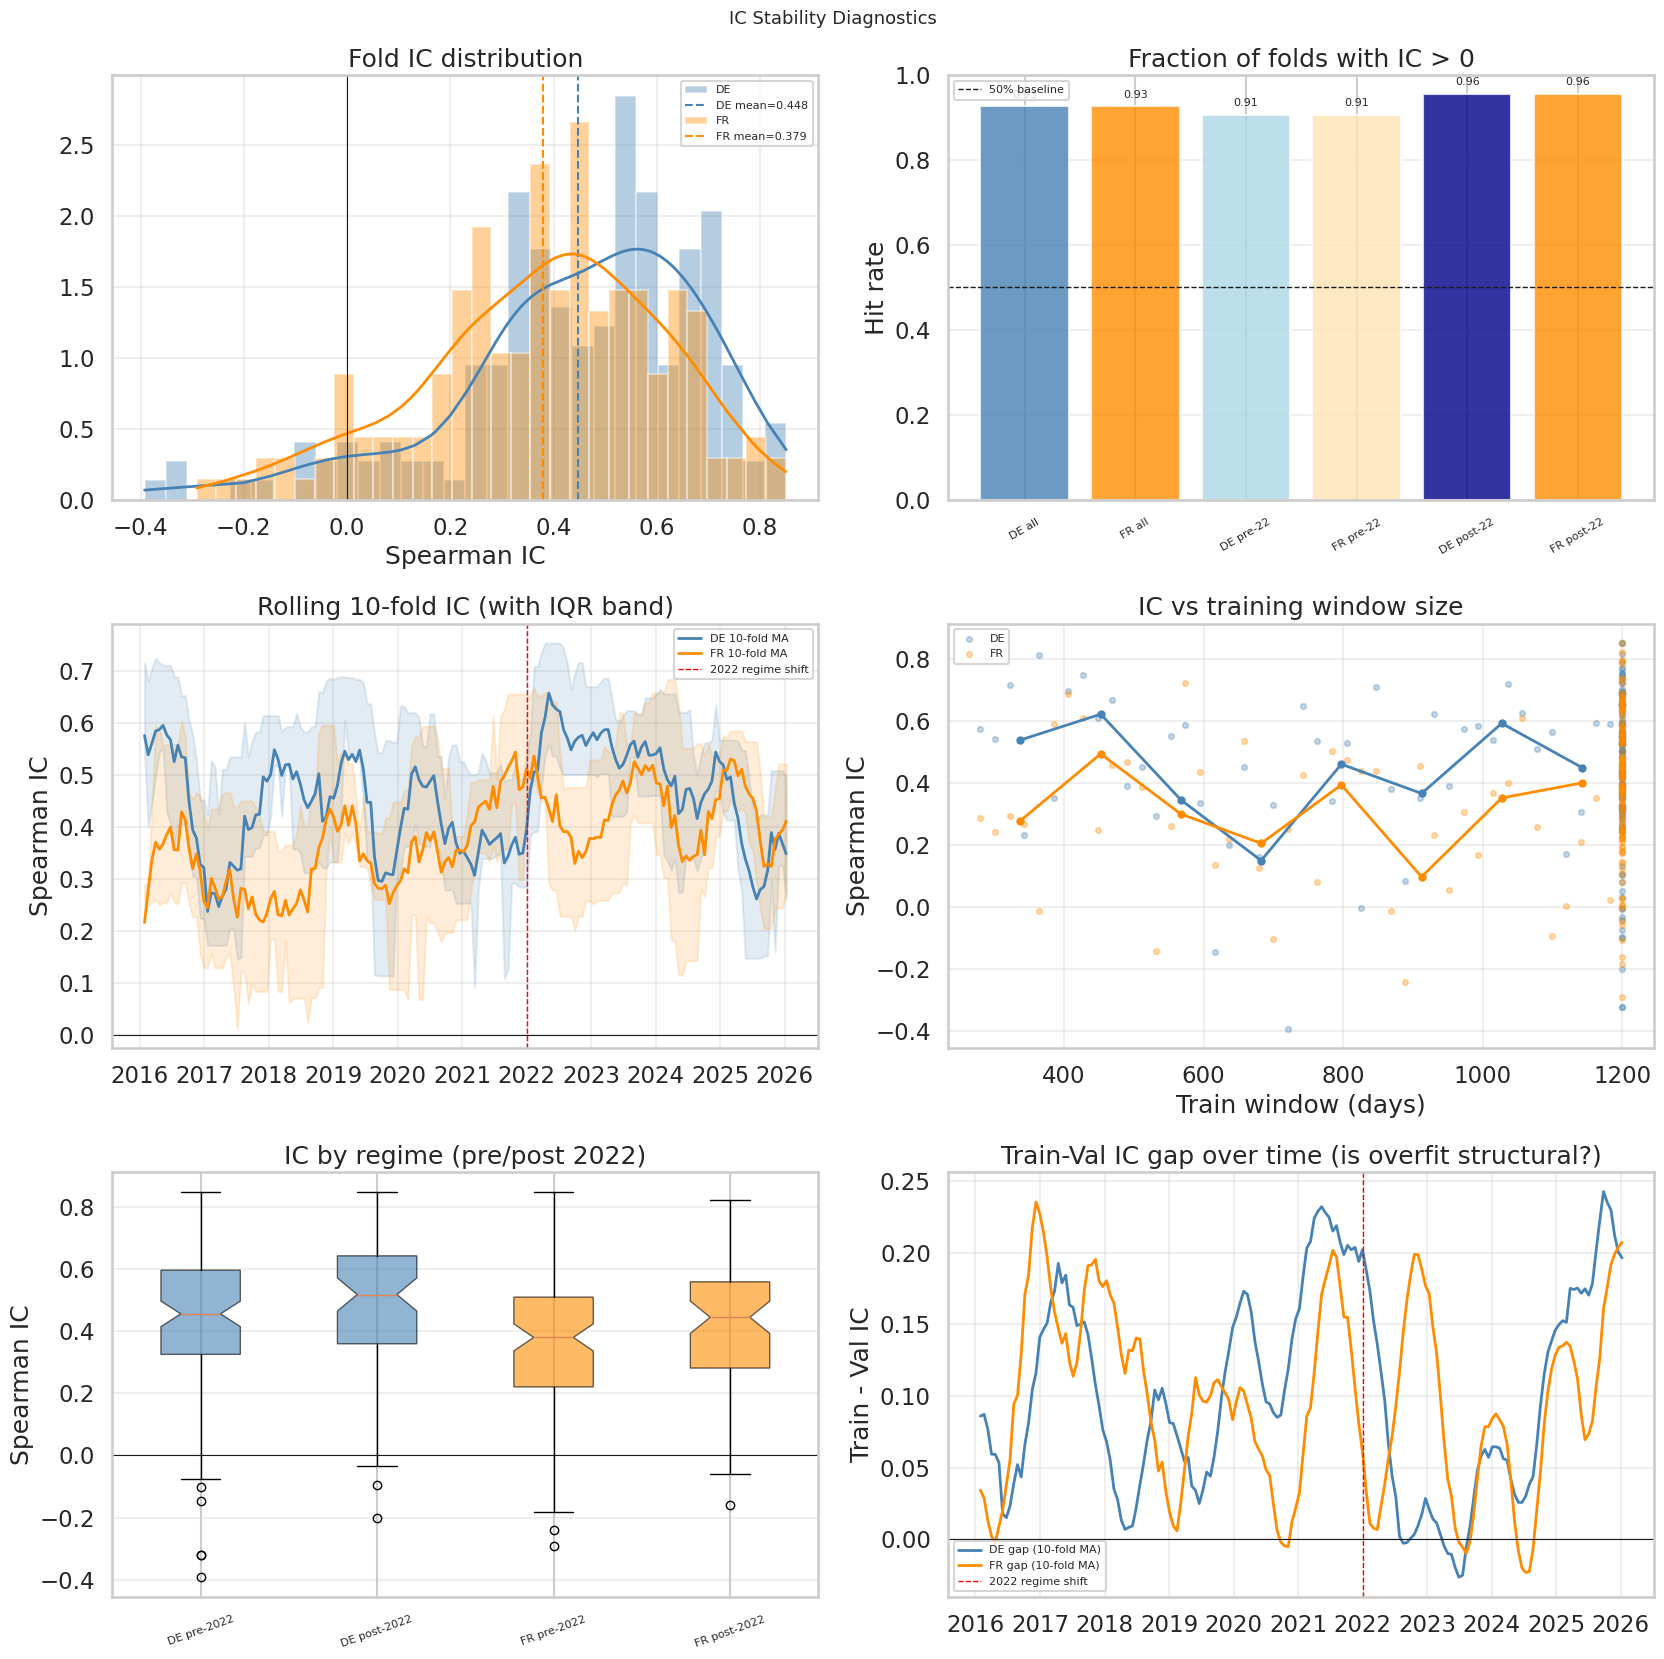


=== IC STABILITY SUMMARY ===

DE:
  Mean IC:          0.4483
  Std IC:           0.2398
  IC / Std (IR):    1.869   (>0.5 ok, >1.0 good)
  Hit rate (IC>0):  0.927
  Pre-2022 mean:    0.4290  (n=108)
  Post-2022 mean:   0.4781  (n=70)
  t-test vs 0:      t=24.94, p=0.0000  (significant)
  Pre vs post t:    t=1.34, p=0.1823  (no significant regime difference)

FR:
  Mean IC:          0.3793
  Std IC:           0.2308
  IC / Std (IR):    1.643   (>0.5 ok, >1.0 good)
  Hit rate (IC>0):  0.927
  Pre-2022 mean:    0.3480  (n=108)
  Post-2022 mean:   0.4275  (n=70)
  t-test vs 0:      t=21.93, p=0.0000  (significant)
  Pre vs post t:    t=2.27, p=0.0242  (regimes differ)


In [58]:
plot_ic_stability(cv_metrics['folds'], rolling_ic=cv_metrics['rolling_ic'])

# Trading strategy + diagnostics block 

- Calm regime -- trading based on log_rv predictions, high-vol -- vol residual predictions
- Both dimensionless and results converted to EUR are available

In [59]:
# Build price panel from EMBER files 
price_panel = build_price_panel(
    price_file_de="european_wholesale_electricity_price_data_hourly/Germany.csv",
    price_file_fr="european_wholesale_electricity_price_data_hourly/France.csv",
)

Price panel: 3781 days  2015-01-01 to 2026-02-14
  DE: mean=76.6  median=46.6  max=691.2 EUR/MWh
  FR: mean=80.6  median=50.9  max=743.8 EUR/MWh


In [60]:
rv_cols = panel_harrv_res[['DATE','DE_realized_vol','FR_realized_vol']].drop_duplicates('DATE')
all_preds_rv = all_preds.merge(rv_cols, on='DATE', how='left')

# Compute rolling calm scale from CV fold history 
bt_with_scale = merge_rolling_scale_into_bt(
    all_preds_rv,           
    cv_metrics['folds'],    
    ic_lookback_folds=20,
    verbose=True,
)

# Run strategy
bt = compute_market_neutral_pnl_adaptive(
    bt_with_scale,
    price_panel=price_panel,
    notional_mw=100.0,
    calm_position_scale=None,       # uses calm_scale_rolling column
    use_sharpe_sizing=True,
    rolling_sharpe_window=63,       # 3 months
    sharpe_floor=0.5,               # scale down below this rolling Sharpe
    eur_scaling_method='regime',    # median across regime, preserves regime specifics
    cost_bps=0.005,
    verbose=True,
)

# Evaluate
metrics, daily_pnl = evaluate_trading_performance(bt, "50bps", notional_mw=100.0)


Rolling calm_position_scale (from past 20 folds):
  Mean=0.872  Std=0.176  Min=0.368  Max=1.000
  First 5 folds use default scale=1.0 (insufficient history)
calm_position_scale: rolling (from past fold ICs)  mean=0.872  min=0.368  max=1.000
Sharpe control: full size 88.6% of days | reduced 11.4% | near-flat 8.7%
EUR: regime scale, calm_median=54.5, hv_median=44.7 EUR/MWh
Market neutrality: OK: 1.11e-16
DE high-vol: 983/3738 (26.3%)
FR high-vol: 1001/3738 (26.8%)
Cost rate: 50.0 bps per unit turnover

=== Trading Performance [50bps] | 100 MW ===
Sharpe:             2.8626  (before cost: 3.0613)
Sortino:            4.4245
Calmar:             1.1917
Max Drawdown:       -10.7261
Win Rate (all):     43.23%
Win Rate (active):  55.96%
Avg Daily Turnover: 0.7012
Total PnL:          189.6111
Total Cost:         13.1050
PnL Before Cost:    202.7161
Cost Coverage:      15.47x

Sharpe control:     full 88.7% | reduced 11.3% | near-flat 8.7%

--- EUR metrics ---
Sharpe EUR:         2.8957  (before

In [61]:
daily_pnl = bt.groupby('DATE')['pnl'].sum()
daily_pnl_eur = bt.groupby('DATE')['pnl_eur'].sum()

print(daily_pnl_eur.quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

left = abs(daily_pnl_eur.quantile(0.1))
right = daily_pnl_eur.quantile(0.9)
print("Asymmetry ratio (right/left):", right/left)

0.10   -26187.230709
0.25    -5530.949087
0.50        0.000000
0.75    15851.909091
0.90    49158.756640
Name: pnl_eur, dtype: float64
Asymmetry ratio (right/left): 1.8772033280804847


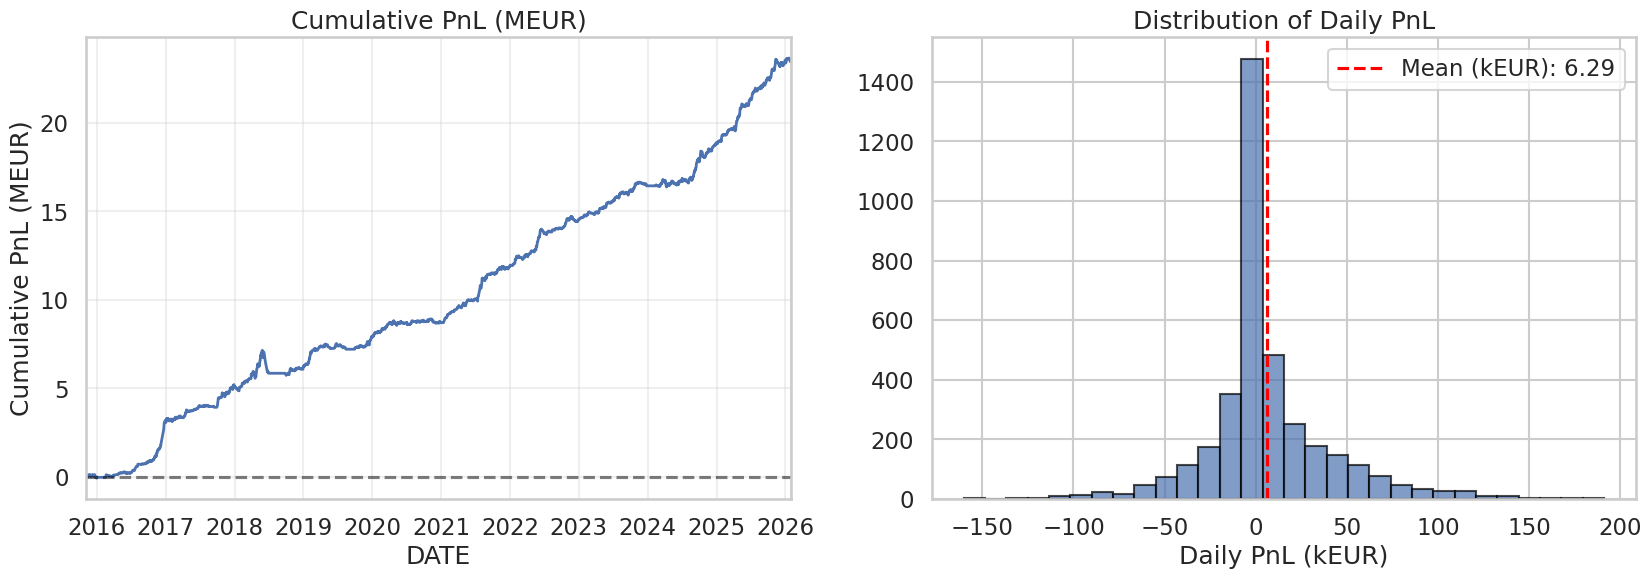

In [66]:
# 3. Cumulative PnL
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
cum_pnl = daily_pnl_eur.cumsum()/1e6
cum_pnl.plot(ax=axes[0], title='Cumulative PnL (MEUR)', linewidth=2)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Cumulative PnL (MEUR)')
axes[0].grid(True, alpha=0.3)

# 4. Daily PnL distribution
axes[1].hist(daily_pnl_eur.dropna()/1e3, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(daily_pnl_eur.mean()/1e3, color='red', linestyle='--',
                   label=f'Mean (kEUR): {daily_pnl_eur.mean()/1e3:.2f}')
axes[1].set_title('Distribution of Daily PnL')
axes[1].set_xlabel('Daily PnL (kEUR)')
axes[1].legend();